In [44]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

from scipy.interpolate import interp1d
import math
from datetime import datetime
from tqdm import tqdm
from sklearn.manifold import TSNE

import pickle


# umineko

In [45]:
def get_info_from_csv(p):
    # 使用 os.path.basename() 获取路径中的最后一个文件名
    file_name = os.path.basename(p)
    # file_name   
    # 去掉扩展名
    file_name_without_extension = file_name.rsplit('.', 1)[0]
    
    # 按下划线分割
    parts = file_name_without_extension.split('_')
    
    # 提取所需的信息
    # 假设你需要的固定模式是：<name><year>_<other>_<code>_<id>
    name_year = parts[0]  # 如 'Umineko2022'
    code = parts[-2]       # 如 'LB09'
    
    # 将 'Umineko2022' 分成 'Umineko' 和 '2022'
    name = ''.join(filter(str.isalpha, name_year))  # 提取字母部分
    year = ''.join(filter(str.isdigit, name_year))  # 提取数字部分
    
    # 将提取的信息放入数组
    result = [name.lower(), int(year), code]
    return result

In [46]:
# get back label 0 or 1 
# 因为有些传感器的位置不同，需要另一个csv文件标记

back_label_path = r'D:\logbot-data\BioTaggerData\masterLabelsByOtsuka\animal_id.csv' 
back_label_pd = pd.read_csv(back_label_path)

def get_backid_samplerate(result):
    [species, year, tag] = result
    # filtering
    filtered_rows = back_label_pd[(back_label_pd['species'] == species) &
                                  (back_label_pd['animal_tag'] == tag)  &
                                  (back_label_pd['year'] == year)]
    
    # Get the values from column C for the filtered rows
    result_values = [0, 0]
    result_values[0] = filtered_rows['back'].values[0]
    result_values[1] = filtered_rows['acc_sampling_rate'].values[0]
    return result_values


In [47]:
umi_root_path = r'D:\logbot-data\BioTaggerData\export\raw\umineko\v.1.0.0'

# because it contains data of three years, try to extract data separately

year_list = [2018, 2019, 2022]

# get all filenames 
file_paths = {}
# Iterate over all files in the directory
for filename in os.listdir(umi_root_path):
    # Check if the file is a CSV file
    if filename.endswith('.csv'):
        file_path = os.path.join(umi_root_path, filename)
        # get file paths and save them by year
        for y in year_list:
            if file_paths.get(y) is not None:
                file_paths[y].append(file_path)
            else:
                file_paths.setdefault(y, []).append(file_path)
        # # Read the CSV file into a DataFrame
        # df = pd.read_csv(file_path)
        # # Append the DataFrame to the list
        # dataframes.append(df)

In [48]:
def format_timestamp(df):
    # if 'datetime' not in df.columns:
    s = df['timestamp'].str.replace('T', ' ').str.replace('Z', '')
    # df = df.drop('timestamp', axis=1)
    s_datetime = pd.to_datetime(s)  # to datetime64[ns]
    df.insert(loc=0, column='datetime', value=s_datetime)
    # round at 1 millisecond
    df['datetime'] = df['datetime'].dt.round('1L')
    # unixtime
    unixtime = df['datetime'].apply(lambda t: t.timestamp())
    df.insert(loc=1, column='unixtime', value=unixtime)
    return df

In [49]:
def check_if_has_str(listdata):
    # check if a list contains string values
    for l in listdata:
        if type(l) == str:
            return True
    return False

def resampling(df, intermediate_sampling_rate=100, output_sampling_rate=25):
    if np.sum(df['unixtime'].duplicated()) > 1:
        # print(len(df[df['unixtime'].duplicated()]))
        df.drop_duplicates(subset='datetime', keep=False, inplace=True)
        # print(len(df[df['unixtime'].duplicated()]))
        print("duplicated index detected -> duplicates removed")
    else:
        print("No duplicates")

    # Generate original time indices
    original_time = np.arange(len(df)) / intermediate_sampling_rate
    # Generate new time indices
    new_length = int(len(df) * output_sampling_rate / intermediate_sampling_rate)
    new_time = np.arange(new_length) / output_sampling_rate
    # Create a new DataFrame to store the resampled values
    resampled_df = pd.DataFrame(index=new_time)
    for column in df.columns:
        # Step 1: Extract unique characters from the column
        unique_chars = df[column].unique()

        if check_if_has_str(unique_chars):

            # Step 2: Create a dictionary that maps each character to a unique integer
            char_to_int = {char: i for i, char in enumerate(unique_chars, start=1)}
            # Step 3: Use the dictionary to replace the characters with their corresponding integers
            df[column] = df[column].map(char_to_int)

            # Create interpolation function for each column
            interp_func = interp1d(original_time, df[column].values, kind='linear', fill_value='extrapolate')
            # Generate new values at the new sampling rate
            resampled_df[column] = interp_func(new_time)

            # Step 4: Create an inverse mapping dictionary
            int_to_char = {v: k for k, v in char_to_int.items()}
            # Step 5: Use the inverse mapping dictionary to convert the integers back to the original characters
            resampled_df[column] = resampled_df[column].map(int_to_char)
        else:
            # Create interpolation function for each column
            interp_func = interp1d(original_time, df[column].values, kind='linear', fill_value='extrapolate')
            # Generate new values at the new sampling rate
            resampled_df[column] = interp_func(new_time)

    resampled_df.drop(columns=['index'], inplace=True)
    return resampled_df

In [50]:
# read csv files as dataframe
## remove nan rows

# Initialize an empty DataFrame
df_list, df_clean_list = [], []
standardHz = 25

for year, path_list in file_paths.items():
    df = pd.DataFrame()
    df_cleaned = pd.DataFrame()
    for p in path_list:
        tp = pd.read_csv(p, dtype={"logger_id": "string", 
                                   "animal_tag": "string",
                                   "timestamp": "string",
                                   "acc_x": "float",
                                   "acc_y": "float",
                                   "acc_z": "float",
                                   # "latitude": "float",
                                   # "longitude": "float",
                                   # "gps_status": "string",
                                   "gyro_x": "float",
                                   "gyro_y": "float",
                                   "gyro_z": "float",
                                   # "mag_x": "float",
                                   # "mag_y": "float",
                                   # "mag_z": "float",
                                   # "illumination": "float",
                                   # "pressure": "float",
                                   # "temperature": "float",
                                   # "activity_class": "int",
                                   "label": "string",
                                   })
        
        tp = format_timestamp(tp)  # 在这里timestamp字符串生成datetime和unixtime
        
        tp['year'] = int(year)  # add a new column
        
        csv_info = get_info_from_csv(p)
        [backID, sample_rate] = get_backid_samplerate(csv_info)
        tp['back'] = int(backID)  # add a backID column, identify position of sensor
        tp['species'] = csv_info[0]  # add a species(umineko) column
        
        # same sampling rate of each csv file, now assume 25Hz
        if sample_rate != standardHz:
            print('resampling to 25Hz...')
            # 先把timestamp保存下来
            save_t = tp.timestamp.values
            # delete timestamp
            tp =tp.drop('timestamp', axis=1)
            
            # If the data frame contains more than one minute of recordings,
            # use the data frame, otherwise, discard it.
            tp.reset_index(inplace=True)
            # if check_df == True:
            #     display(df_list[i].head(5))
            print('length of previous data is %d'%len(tp))
            tp = resampling(
                df=tp,
                intermediate_sampling_rate=sample_rate,
                output_sampling_rate=standardHz
            )
            print('length of new data is %d'%len(tp))

            tp['timestamp'] = tp['datetime'].apply(
            lambda x:datetime.utcfromtimestamp(float(x/1000000000.0)).strftime('%Y-%m-%dT%H:%M:%S.%f')[:-3]+'Z')

            
        tp_cleaned = tp.dropna(subset=['label'])
        
        # If the DataFrame is empty, initialize it with the first data
        if df.empty:
            df = tp
            df_cleaned = tp_cleaned
        else:
            # Otherwise, concatenate the new data to the existing DataFrame
            df = pd.concat([df, tp], ignore_index=True)
            df_cleaned = pd.concat([df_cleaned, tp_cleaned], ignore_index=True)
        
        
        # break
    df_list.append(df)
    df_clean_list.append(df_cleaned)
    # break

resampling to 25Hz...
length of previous data is 921258
No duplicates
length of new data is 742950
resampling to 25Hz...
length of previous data is 886972
No duplicates
length of new data is 715300
resampling to 25Hz...
length of previous data is 932573
No duplicates
length of new data is 752075
resampling to 25Hz...
length of previous data is 1316260
No duplicates
length of new data is 1061500
resampling to 25Hz...
length of previous data is 921258
No duplicates
length of new data is 742950
resampling to 25Hz...
length of previous data is 886972
No duplicates
length of new data is 715300
resampling to 25Hz...
length of previous data is 932573
No duplicates
length of new data is 752075
resampling to 25Hz...
length of previous data is 1316260
No duplicates
length of new data is 1061500
resampling to 25Hz...
length of previous data is 921258
No duplicates
length of new data is 742950
resampling to 25Hz...
length of previous data is 886972
No duplicates
length of new data is 715300
resamp

In [51]:
df_cleaned.head(2)

,datetime,unixtime,logger_id,animal_tag,timestamp,acc_x,acc_y,acc_z,latitude,longitude,...,mag_y,mag_z,illumination,pressure,temperature,activity_class,label,year,back,species
0,2018-05-25 01:16:04.560000,1.527211e+09,lb0001,LB07,2018-05-25T01:16:04.560Z,0.249023,-0.009277,0.833008,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ground_stationary,2022.0,1.0,umineko
1,2018-05-25 01:16:04.600000,1.527211e+09,lb0001,LB07,2018-05-25T01:16:04.600Z,0.238281,-0.005859,0.821777,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ground_stationary,2022.0,1.0,umineko


In [16]:
a= []
for f in df_clean_list:
    print(np.unique(f.label))
    a.extend(list(np.unique(f.label)))

['bathing' 'bathing_poss' 'body_shaking' 'flying_active' 'flying_passive'
 'foraging' 'foraging_fish_poss' 'foraging_insect_poss'
 'foraging_non-fish' 'foraging_poss' 'foraging_steal' 'forgaing_insect'
 'ground_active' 'ground_stationary' 'poss_foraging' 'preening'
 'stationary' 'unknown']
['bathing' 'bathing_poss' 'body_shaking' 'flying_active' 'flying_passive'
 'foraging' 'foraging_fish_poss' 'foraging_insect_poss'
 'foraging_non-fish' 'foraging_poss' 'foraging_steal' 'forgaing_insect'
 'ground_active' 'ground_stationary' 'poss_foraging' 'preening'
 'stationary' 'unknown']
['bathing' 'bathing_poss' 'body_shaking' 'flying_active' 'flying_passive'
 'foraging' 'foraging_fish_poss' 'foraging_insect_poss'
 'foraging_non-fish' 'foraging_poss' 'foraging_steal' 'forgaing_insect'
 'ground_active' 'ground_stationary' 'poss_foraging' 'preening'
 'stationary' 'unknown']


In [18]:
np.unique(a)

array(['bathing', 'bathing_poss', 'body_shaking', 'flying_active',
       'flying_passive', 'foraging', 'foraging_fish_poss',
       'foraging_insect_poss', 'foraging_non-fish', 'foraging_poss',
       'foraging_steal', 'forgaing_insect', 'ground_active',
       'ground_stationary', 'poss_foraging', 'preening', 'stationary',
       'unknown'], dtype='<U20')

### just select umineko, 2018, back=1

In [52]:
selected_df = df_clean_list[0].copy()
selected_df = selected_df[(selected_df['year'] == 2018) &
                          (selected_df['back'] == 1)  &
                          (selected_df['species'] == 'umineko')]    
len(selected_df)

405419

In [62]:
selected_df0 = df_clean_list[0].copy()
selected_df0 = selected_df0[(selected_df0['year'] == 2018) &
                          (selected_df0['back'] == 0)  &
                          (selected_df0['species'] == 'umineko')]   

# create dataloader

In [53]:
def sliding_window(data, len_sw):
    # input is a segment of data
    # output is data, timestamp, domain(filename), label
    # sampling rate = 25Hz
    # window size = 900, step = window size/2
    # for umineko data, 目前只处理有标签的data，用slidewin取segment时，保证最后一块segment一定取到。
    # 同时，以每个单独的标签（起止时间）为单位，不要把其他时间的不同label的segment混在一起。

    # batch_size = 512
    # len_sw = 90
    step = int(len_sw / 2)

    if isinstance(data, pd.DataFrame):
        data1 = data.copy()
        datanp = data1.values
    else:
        datanp = data.copy()

    # generate batch of data by overlapping the training set
    data_batch = []
    for idx in range(0, datanp.shape[0] - len_sw - step, step):  # step10
        data_batch.append(datanp[idx: idx + len_sw, :])
    data_batch.append(datanp[-1 - len_sw: -1, :])  # last batch
    xlist = np.stack(data_batch, axis=0)  # [B, Len90, dim6]
    # [samples, timestamps, labels] = xlist
    # x_win_train = xlist.reshape((batch_size, xlist.shape[1], xlist.shape[-1]))  # [B, Len, dim]
    # print(" ..after sliding window: train inputs {0}".format(xlist.shape))
    return xlist

In [54]:
def process_pressure_sensor(df, columns):
    if 'pressure' in columns:
        df['pressure'] = df['pressure'] - 1013.25
    return df

In [55]:
def process_gps(df):
    # identify if gps exists
    # if exists, calculate velocity and angle
    gps_len = len(df)
    df_columns = df.columns
    if ('latitude' in df_columns) or\
        ('longitude' in df_columns):
        # Extract rows where both latitude and longitude are not NaN
        df_non_nan = df.dropna(subset=['latitude', 'longitude'])

        # get sampling rate of GPS signal,newlen*oldHz/oldlen得到GPShz，所以这里传newlen
        gps_len = len(df_non_nan)

        # Calculate differences, handling NaN by filling with zeros
        df_non_nan['lat_diff'] = np.radians(df_non_nan['latitude'].diff())
        df_non_nan['lon_diff'] = np.radians(df_non_nan['longitude'].diff())

        # Convert latitude to radians, handling NaN by filling with zeros
        df_non_nan['lat1'] = np.radians(df_non_nan['latitude'].shift())
        df_non_nan['lat2'] = np.radians(df_non_nan['latitude'])

        # Calculate time difference in seconds
        df_non_nan['timestamp'] = pd.to_datetime(df_non_nan['timestamp'])
        df_non_nan['time_diff'] = df_non_nan['timestamp'].diff().dt.total_seconds()

        # Haversine formula
        a = (np.sin(df_non_nan['lat_diff'] / 2) ** 2 +
             np.cos(df_non_nan['lat1']) * np.cos(df_non_nan['lat2']) * np.sin(df_non_nan['lon_diff'] / 2) ** 2)
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        R = 6371000  # Earth radius in meters
        df_non_nan['distance'] = R * c
        # Calculate velocity (m/s)
        df_non_nan['GPS_velocity'] = df_non_nan['distance'] / df_non_nan['time_diff']

        # Calculate bearing
        x = np.sin(df_non_nan['lon_diff']) * np.cos(df_non_nan['lat2'])
        y = (np.cos(df_non_nan['lat1']) * np.sin(df_non_nan['lat2']) -
             np.sin(df_non_nan['lat1']) * np.cos(df_non_nan['lat2']) * np.cos(df_non_nan['lon_diff']))
        initial_bearing = np.arctan2(x, y)
        initial_bearing = np.degrees(initial_bearing)
        df_non_nan['GPS_bearing'] = (initial_bearing + 360) % 360

        # Merge velocity and bearing back to the original dataframe
        df = df.merge(df_non_nan[['GPS_velocity', 'GPS_bearing']], left_index=True, right_index=True, how='left')

    return df, gps_len

In [56]:
# add velocity and angles if GPS sensor exists
df, gps_len = process_gps(selected_df)


C:\Users\dell\AppData\Local\Temp\ipykernel_29960\4155312388.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_nan['lat_diff'] = np.radians(df_non_nan['latitude'].diff())
C:\Users\dell\AppData\Local\Temp\ipykernel_29960\4155312388.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_nan['lon_diff'] = np.radians(df_non_nan['longitude'].diff())
C:\Users\dell\AppData\Local\Temp\ipykernel_29960\4155312388.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [63]:
# add velocity and angles if GPS sensor exists
df0, gps_len = process_gps(selected_df0)
with open('raw_data_umineko2018_b0.pkl', 'wb') as f:
    pickle.dump(df0, f)

C:\Users\dell\AppData\Local\Temp\ipykernel_29960\4155312388.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_nan['lat_diff'] = np.radians(df_non_nan['latitude'].diff())
C:\Users\dell\AppData\Local\Temp\ipykernel_29960\4155312388.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_nan['lon_diff'] = np.radians(df_non_nan['longitude'].diff())
C:\Users\dell\AppData\Local\Temp\ipykernel_29960\4155312388.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [64]:

with open('raw_data_umineko2018_b1.pkl', 'wb') as f:
    pickle.dump(df, f)

In [67]:
with open('raw_data_umineko2018_b1.pkl', 'rb') as f:
    df = pickle.load(f)
with open('raw_data_umineko2018_b0.pkl', 'rb') as f:
    df0 = pickle.load(f)

In [68]:

# fulfill nan values
df = df.bfill().ffill()

# get label id from label string
label_dict = {
  'ground_stationary': 0,
  'stationary': 0,
  'preening': 0,
  'bathing': 1,
    'bathing_poss': 1,
    'body_shaking': 6,
    'flying_active': 7,
    'flying_passive': 7,
    'foraging': 4,
    'foraging_fish_poss': 4,
    'foraging_insect_poss': 4,
    'foraging_non-fish': 4,
    'foraging_poss': 4,
    'ground_active': 8,
  'flight_take_off': 2,
  'flight_cruising': 3,
  'foraging_dive': 4,
  'surface_seizing': 5,
  'unknown': -1,
  }
df['label_id'] = df['label'].map(label_dict)  

columns = ['timestamp',
            'acc_x', 'acc_y', 'acc_z', 
           # 'latitude', 'longitude', 'gps_status', 
           'GPS_velocity', 'GPS_bearing',
           'gyro_x', 'gyro_y', 'gyro_z', 
           'mag_x', 'mag_y', 'mag_z', 
           'illumination',
           'pressure', 
           'temperature',
           'label_id',
           'animal_tag']  # without timestamps
df_ready = process_pressure_sensor(df, columns)
df_ready = df_ready[columns]  # save df_ready

In [69]:

# fulfill nan values
df0 = df0.bfill().ffill()

df0['label_id'] = df0['label'].map(label_dict)  

columns = ['timestamp',
           'acc_x', 'acc_y', 'acc_z', 
           # 'latitude', 'longitude', 'gps_status', 
           'GPS_velocity', 'GPS_bearing',
           'gyro_x', 'gyro_y', 'gyro_z', 
           'mag_x', 'mag_y', 'mag_z', 
           'illumination',
           'pressure', 
           'temperature',
           'label_id',
           'animal_tag']  # without timestamps
df_ready0 = process_pressure_sensor(df0, columns)
df_ready0 = df_ready0[columns]  # save df_ready

In [70]:
# save train and test

with open('data_b1.pkl', 'wb') as f:
    pickle.dump(df_ready, f)
with open('data_b0.pkl', 'wb') as f:
    pickle.dump(df_ready0, f)
    
# with open('loaders.pkl', 'wb') as f:
#     pickle.dump([train_loader, test_loaders], f)
# with open('loaders.pkl', 'rb') as f:
#     [train_loader, test_loaders] = pickle.load(f)
# with open('data.pkl', 'rb') as f:
#     df_ready = pickle.load(f)

In [37]:
class data_loader_umineko(Dataset):
    def __init__(self, samples, labels, device='cpu'):
        self.samples = torch.tensor(samples).to(device)  # check data type
        self.labels = torch.tensor(labels)  # check data type

    def __getitem__(self, index):
        target = self.labels[index]
        sample = self.samples[index]
        return sample, target

    def __len__(self):
        return len(self.labels)
    


In [38]:
# prepare train loader of accelerometer
sensor_type = 'accel'
batch_size = 512
device = 'cuda'
len_sw = 180
selected_columns = ['acc_x', 'acc_y', 'acc_z', 
                   'label_id']  # without timestamps
tmp_b = sliding_window(df_ready[selected_columns], len_sw)

# concatenate list
data_b = tmp_b[:,:,:-1]  # [B, Len, dim-1]
label_b = tmp_b[:,:,-1]  # [B, Len]

In [39]:
data_b.shape

(4503, 180, 3)

In [40]:
label_b.shape

(4503, 180)

In [41]:
train_set_r = data_loader_umineko(data_b, label_b, device=device)
train_loader = DataLoader(train_set_r, batch_size=batch_size,
                           shuffle=False, drop_last=False)

In [42]:
# 每一个文件为一个test loader
test_filenames = df_ready.animal_tag.unique()
test_loaders = []
for f in test_filenames:
    single_df = df_ready[df_ready['animal_tag']==f]
    tmp_b = sliding_window(single_df[selected_columns], len_sw)
    # concatenate list
    data_b = tmp_b[:,:,:-1]  # [B, Len, dim-1]
    label_b = tmp_b[:,:,-1]  # [B, Len]
    test_set_r = data_loader_umineko(data_b, label_b, device=device)
    test_loader = DataLoader(test_set_r, batch_size=batch_size,
                           shuffle=False, drop_last=False)
    test_loaders.append(test_loader)

In [60]:
len(test_loaders)

9

# prepare model

In [61]:
class CNN_AE_encoder(nn.Module):
    def __init__(self, n_channels, out_channels=128):
        super(CNN_AE_encoder, self).__init__()

        self.n_channels = n_channels * 2

        self.linear = nn.Linear(n_channels, self.n_channels)
        kernel_size = 5
        self.e_conv1 = nn.Sequential(nn.Conv2d(self.n_channels, 32,
                                               (1, kernel_size), bias=False,
                                               padding=(0, kernel_size // 2)),
                                     nn.BatchNorm2d(32),
                                     nn.PReLU())  # Tanh is MoIL paper
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2, padding=0, return_indices=True)
        self.dropout = nn.Dropout(0.35)  # probability of samples to be zero

        self.e_conv2 = nn.Sequential(nn.Conv2d(32, 64,
                                               (1, kernel_size), bias=False,
                                               padding=(0, kernel_size // 2)),
                                     nn.BatchNorm2d(64),
                                     nn.PReLU())
        self.pool2 = nn.MaxPool1d(kernel_size=4, stride=2, padding=0, return_indices=True)

        self.e_conv3 = nn.Sequential(nn.Conv2d(64, out_channels,
                                               (1, kernel_size), bias=False,
                                               padding=(0, kernel_size // 2)),
                                     nn.BatchNorm2d(out_channels),
                                     nn.PReLU())
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2, padding=0, return_indices=True)

        self.out_samples = 25
        self.out_dim = out_channels

        return

    def forward(self, x_input):  # x(batch,len180,dim6)
        x = self.linear(x_input)
        x = x.unsqueeze(2).permute(0, 3, 2, 1)  # outx(batch,dim,1,len)
        x1 = self.e_conv1(x)  # x1(batch,64,1,180)
        x1 = x1.squeeze(2)  # batch,32,180
        x, indice1 = self.pool1(x1)  # (batch,32,90)len减半,最后一维maxpool
        x = x.unsqueeze(2)
        x = self.dropout(x)
        # ---------
        x2 = self.e_conv2(x)  # batch,64,90
        x2 = x2.squeeze(2)
        x, indice2 = self.pool2(x2)
        x = x.unsqueeze(2)  # batch,64,45
        x = self.dropout(x)
        # ---------
        x3 = self.e_conv3(x)  # batch,128,45
        x3 = x3.squeeze(2)
        x_encoded, indice3 = self.pool3(x3)  # xencoded(batch,128,15)
        # x_encoded # batch,128,15
        return x_encoded, [indice1, indice2, indice3]


class CNN_AE_decoder(nn.Module):
    def __init__(self, n_channels, out_channels=128):
        super(CNN_AE_decoder, self).__init__()

        self.n_channels = n_channels
        kernel_size = 5
        self.unpool1 = nn.MaxUnpool1d(kernel_size=2, stride=2, padding=0)
        self.d_conv1 = nn.Sequential(nn.ConvTranspose2d(out_channels, 64,
                                                        kernel_size=(1, kernel_size),
                                                        bias=False,
                                                        padding=(0, kernel_size // 2)),
                                     nn.BatchNorm2d(64),
                                     nn.PReLU())

        self.unpool2 = nn.MaxUnpool1d(kernel_size=4, stride=2, padding=0)
        self.d_conv2 = nn.Sequential(nn.ConvTranspose2d(64, 32,
                                                        kernel_size=(1, kernel_size),
                                                        stride=1, bias=False,
                                                        padding=(0, kernel_size // 2)),
                                     nn.BatchNorm2d(32),
                                     nn.PReLU())

        self.unpool3 = nn.MaxUnpool1d(kernel_size=2, stride=2, padding=0)
        self.d_conv3 = nn.Sequential(nn.ConvTranspose2d(32, n_channels,
                                                        kernel_size=(1, kernel_size),
                                                        stride=1, bias=False,
                                                        padding=(0, kernel_size // 2)),
                                     nn.BatchNorm2d(n_channels),
                                     nn.PReLU())

        self.linear = nn.Linear(n_channels, 3)
        if n_channels == 3:  # acc,gyro, where data length is 90
            self.reshapel = nn.Linear(89, 90)
        else:
            self.reshapel = nn.Linear(29, 30)
        return

    def forward(self, x_encoded, encode_indices):  # x_encoded(batch, 128, 25)
        x = self.unpool1(x_encoded, encode_indices[-1])  # out(batch, 64, 47)
        x = x.unsqueeze(2)
        x = self.d_conv1(x)  # out(batch, 128, 45)
        x = x.squeeze(2)
        # x = self.lin1(x)
        # ---------
        x = self.unpool2(x, encode_indices[-2])  # out(batch, 64, 90)
        x = x.unsqueeze(2)
        x = self.d_conv2(x)  # out(batch, 32, 91)
        x = x.squeeze(2)
        # ---------
        x = self.unpool3(x, encode_indices[0])  # x_decoded(batch,32,180)
        x = x.unsqueeze(2)
        x_decoded = self.d_conv3(x)
        x_decoded = x_decoded.squeeze(2)  # batch, 6, 180 = AE input
        # x_decoded = self.reshapel(x_decoded)
        # x_decoded = self.linear(x_decoded)
        return x_decoded


In [62]:
class CNN_AE(nn.Module):
    def __init__(self, n_channels, out_channels=128):
        super(CNN_AE, self).__init__()

        # self.backbone = backbone
        self.n_channels = n_channels  # input data dimension

        self.lin2 = nn.Identity()
        # self.out_dim = 25 * out_channels


        self.encoder = CNN_AE_encoder(n_channels,
                                      out_channels=out_channels)
        self.decoder = CNN_AE_decoder(n_channels,
                                      out_channels=out_channels)

        return

    def forward(self, x):  # x(batch, len180, dim6)
        x_encoded, encode_indices = self.encoder(x)  # x_encoded(batch, 128, 25)
        # todo, encoder output 改成batch,dim
        decod_out = self.decoder(x_encoded, encode_indices)  # x_decoded(batch, 6, 179)

        x_decoded = decod_out.permute(0, 2, 1)
        # x_decoded(batch, 180, 6), x_encoded(batch, 128, 15)
        return x_encoded, x_decoded

In [63]:
class ReconstructionFramework(nn.Module):
    def __init__(self, backbone):
        super(ReconstructionFramework, self).__init__()
        self.backbone = backbone

    def forward(self, x):
        x_encoded, x_decoded = self.backbone(x)
        return x_encoded, x_decoded

In [133]:
out_channels = 32
num_channel = data_b.shape[-1]
backbone = CNN_AE(n_channels=num_channel, out_channels=out_channels)
model = ReconstructionFramework(backbone)
model = model.to(device)

In [38]:
from ae_model import Act2Vec
# with open('loaders.pkl', 'rb') as f:
#     b = pickle.load(f)
with open('data.pkl', 'rb') as f:
    c = pickle.load(f)
    
# out_channels = 32
# device = 'cuda'
# model = Act2Vec(out_channels, input_dim=(4503, 180, 3))
# model = model.to(device)

# training

In [5]:
def adjust_learning_rate(lr, optimizer, epoch, p_scheduler, p_epochs):
    # lr = 0.0001

    if p_scheduler == 'cosine':
        lr_decay_rate = 0.1
        eta_min = lr * (lr_decay_rate ** 3)
        lr = eta_min + (lr - eta_min) * (1 + math.cos(math.pi * epoch / p_epochs)) / 2

    # elif p['scheduler'] == 'step':
    #     steps = np.sum(epoch > np.array(p['scheduler_kwargs']['lr_decay_epochs']))
    #     if steps > 0:
    #         lr = lr * (p['scheduler_kwargs']['lr_decay_rate'] ** steps)

    elif p_scheduler == 'constant':
        lr = lr

    else:
        raise ValueError('Invalid learning rate schedule {}'.format(p_scheduler))

    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    return lr

In [6]:
class MSEloss(nn.Module):
    def __init__(self):
        super(MSEloss, self).__init__()

    def forward(self, input, target):
        '''
        input: raw sensor data
        target: reconstructed sensor data
        the mse loss makes the target data to be similar to the input data
        '''
        loss = nn.MSELoss()
        output = loss(input, target)
        return output

In [7]:
def get_optimizer(p_opti, model):
    params = model.parameters()
    if p_opti == 'sgd':
        optimizer = torch.optim.SGD(params, 
                                    nesterov=False,
                                    weight_decay=0.0001,
                                    momentum=0.9,
                                    lr=0.0001)

    elif p_opti == 'adam':
        optimizer = torch.optim.Adam(params,
                                     weight_decay=0.0001,
                                     lr=0.01)
    else:
        raise ValueError('Invalid optimizer {}'.format(p_opti))
    
    return optimizer


In [8]:
# Criterion
criterion = MSEloss()
criterion = criterion.to(device)

# Optimizer and scheduler
p_opti = 'sgd'
optimizer = get_optimizer(p_opti, model)

In [9]:
class AverageMeter(object):
    def __init__(self, name, fmt=':f'):
        self.name = name
        self.fmt = fmt
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

    def __str__(self):
        fmtstr = '{name} {val' + self.fmt + '} ({avg' + self.fmt + '})'
        return fmtstr.format(**self.__dict__)

In [10]:
def AE_train_time_series(train_loader, model, criterion, optimizer):
    """
    Train according to the scheme from SimCLR
    https://arxiv.org/abs/2002.05709
    """
    losses = AverageMeter('Loss', ':.4e')

    model.train()

    for i, (sample, label) in enumerate(train_loader):
        # aug_sample1 = gen_aug(sample, 't_warp')  # t_warp, out.shape=batch64,width3,height900
        # reshape data by adding channel to 1, and transpose height and width
        # sample = sample.to(device=device, non_blocking=True, dtype=torch.float)
        sample = sample.to(dtype=torch.float)

        # input of autoencoder will be 3D, the backbone is 1d-cnn
        x_encoded, output = model(sample)  # x_encoded.shape=batch512,outchannel128,len13
        loss = criterion(sample, output)
        losses.update(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    #     if i % 10 == 0:
    #         print('loss of the ' + str(epoch) + '-th training epoch is :' + losses.__str__())
    # print('loss of the ' + str(epoch) + '-th training epoch is :' + losses.__str__())
    return losses

In [ ]:
# training
start_epoch = 0
num_epochs = 1000
lr = 0.0001
# i = 1  # 应该一只鸟一个trainloader，暂时全拼接到一起
# print('Starting %s-th bird data' % str(i))
for epoch in tqdm(range(start_epoch, num_epochs)):

    # Adjust lr
    lr_pre = lr
    lr = adjust_learning_rate(lr, optimizer, epoch, p_scheduler='cosine', p_epochs=num_epochs)
    # if (lr != lr_pre):
    #     print('Adjusted learning rate to {:.5f}'.format(lr))

    # Train: the same as simclr
    # print('Train ...')
    losses = AE_train_time_series(train_loader, model, criterion, optimizer)
    if (epoch % 10 == 0) or (epoch == num_epochs-1):
        print('loss of the ' + str(epoch) + '-th training epoch is :' + losses.__str__())

    # print('loss of the ' + str(epoch) + '-th training epoch is :' + losses.__str__())


# Save final model, xx\aaa-bbb-2024-04-24\unsup-models\iteration-0\aaaApr24\train
# column_list = '-'.join(data_column).replace('_','')
print('Saving model at: ' + 'AE_epoch%s' % str(epoch)\
      + '_datalen%s_' % str(len_sw) + sensor_type + '.pth')
torch.save(model.state_dict(), 'AE_epoch%s' % str(epoch) +\
           '_datalen%s_' % str(len_sw) + sensor_type + '.pth')



# test

In [10]:
def reduce_dimension_with_tsne(array, method='tsne'):
    # tsne or pca
    tsne = TSNE(n_components=2)  # 创建TSNE对象，降维到2维
    reduced_array = tsne.fit_transform(array)  # 对数组进行降维
    return reduced_array


In [41]:
full_model_path = r'D:\code\DeepView\deepview\calculate_results\AE_epoch999_datalen180_accel.pth'

if torch.cuda.is_available():
    model.load_state_dict(torch.load(full_model_path, weights_only=False))
else:
    model.load_state_dict(torch.load(full_model_path, weights_only=False, map_location=torch.device('cpu')))


RuntimeError: Error(s) in loading state_dict for Act2Vec:
	size mismatch for layer1.weight_ih_l0: copying a param with shape torch.Size([96, 540]) from checkpoint, the shape in current model is torch.Size([96, 3]).
	size mismatch for layer1.weight_ih_l0_reverse: copying a param with shape torch.Size([96, 540]) from checkpoint, the shape in current model is torch.Size([96, 3]).

In [4]:
def AE_eval_time_series(train_loader, model, device):
    model.eval()

    representation_list = []
    sample_list, timestamp_list, label_list, pred_list, timestr_list, flag_list = [], [], [], [], [], []
    for i, (sample, label) in enumerate(train_loader):
        sample = sample.to(device=device, non_blocking=True, dtype=torch.float)

        # input of autoencoder will be 3D, the backbone is 1d-cnn
        x_encoded, output = model(sample)  # x_encoded.shape=batch512,outchannel128,len13
        # print(type(output))
        # x_encoded, output = model(input_).view(b, 2, -1)  # output.shape=b,2,128, split the first dim into 2 parts
        tmp_representation = x_encoded.detach().cpu().numpy()
        representation_list.append(tmp_representation)
        sample_list.append(sample.detach().cpu().numpy())
        label_list.append(label.detach().cpu().numpy())
        pred_list.append(output.detach().cpu().numpy())

    return representation_list, sample_list, pred_list, label_list

In [8]:
# prepare train loader of accelerometer
with open('data.pkl', 'rb') as f:
    df_ready = pickle.load(f)
sensor_type = 'accel'
batch_size = 512
device = 'cuda'
len_sw = 180
selected_columns = ['acc_x', 'acc_y', 'acc_z',
                   'label_id']  # without timestamps
tmp_b = sliding_window(df_ready[selected_columns], len_sw)

# concatenate list
data_b = tmp_b[:,:,:-1]  # [B, Len, dim-1]
label_b = tmp_b[:,:,-1]  # [B, Len]

train_set_r = data_loader_umineko(data_b, label_b, device=device)
train_loader = DataLoader(train_set_r, batch_size=batch_size,
                           shuffle=False, drop_last=False)

from ae_model import Act2Vec
full_model_path = r'D:\code\DeepView\deepview\calculate_results\AE_GRU_epoch3999_datalen180_accel.pth'
out_channels = 32
model = Act2Vec(out_channels, input_dim=(4503, 180, 3))
device = 'cuda'
model = model.to(device)
if torch.cuda.is_available():
    model.load_state_dict(torch.load(full_model_path, weights_only=False))
else:
    model.load_state_dict(torch.load(full_model_path, weights_only=False, map_location=torch.device('cpu')))

In [11]:
# reconstruction result

representation_list, sample_list, pred_list, label_list = \
            AE_eval_time_series(train_loader, model, device)

# tsne latent representation to shape=(2, len) PCA降维到形状为 (2, len)
repre_concat = np.concatenate(representation_list)
repre_reshape = repre_concat.reshape(repre_concat.shape[0], -1)
repre_tsne = reduce_dimension_with_tsne(repre_reshape)

In [12]:
sample_concat = np.concatenate(sample_list)
pred_concat = np.concatenate(pred_list)
print(sample_concat.shape)
print(pred_concat.shape)
sample_reshape = sample_concat.reshape(-1, sample_concat.shape[-1])
pred_reshape = pred_concat.reshape(-1, pred_concat.shape[-1])
print(sample_reshape.shape)
print(pred_reshape.shape)

(4503, 180, 3)
(4503, 180, 3)
(810540, 3)
(810540, 3)


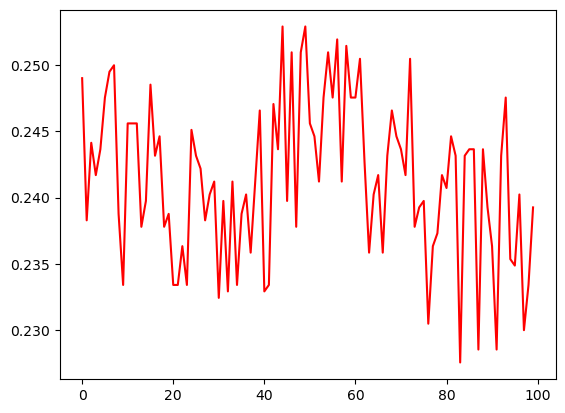

In [146]:
plt.figure(0)

plt.plot(sample_reshape[:100, 0], 'r')
# plt.plot(pred_reshape[:100, 0], 'b.')
plt.show()

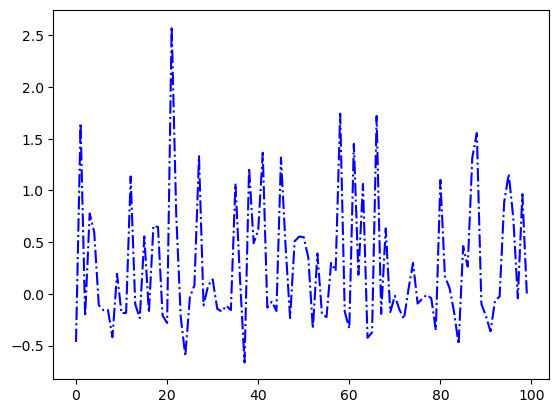

In [132]:
plt.figure(1)

# plt.plot(sample_reshape[:1000, 0], 'r')
plt.plot(pred_reshape[:100, 0], 'b-.')
plt.show()

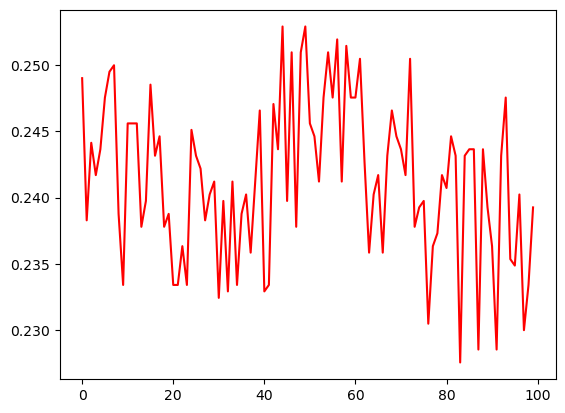

In [15]:
plt.figure(1)  # GRU-epoch3999

plt.plot(sample_reshape[:100, 0], 'r')
# plt.plot(pred_reshape[:100, 0], 'b.')
plt.show()

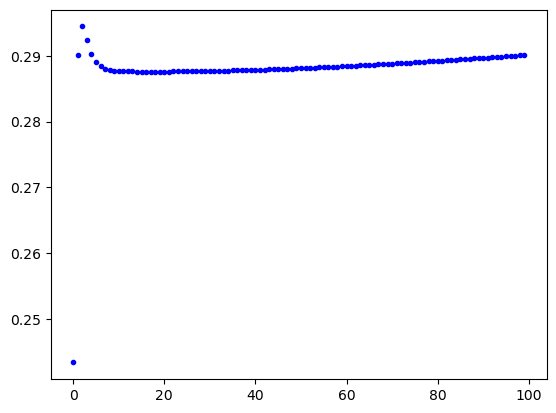

In [16]:
plt.figure(2)  # GRU-epoch3999

# plt.plot(sample_reshape[:100, 0], 'r')
plt.plot(pred_reshape[:100, 0], 'b.')
plt.show()

In [ ]:
# representation of all data



In [ ]:
# representation of one-day data

